In [ ]:
# ============================================================
# Bloch Sphere, Pure & Mixed States
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

In [ ]:
# Pauli matrices and other Utility Functions

sigma_x = np.array([[0,1],[1,0]], dtype=complex)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=complex)
I = np.eye(2)

def bloch_vector_from_density(rho):
    rx = np.real(np.trace(rho @ sigma_x))
    ry = np.real(np.trace(rho @ sigma_y))
    rz = np.real(np.trace(rho @ sigma_z))
    return np.array([rx, ry, rz])

def density_from_bloch(r):
    return 0.5*(I + r[0]*sigma_x + r[1]*sigma_y + r[2]*sigma_z)

def purity(rho):
    return np.real(np.trace(rho @ rho))

def plot_bloch(vectors=[], labels=[]):
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')

    # Sphere
    u = np.linspace(0, 2*np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))

    ax.plot_surface(x, y, z, alpha=0.1)

    # Axes
    ax.quiver(0,0,0,1,0,0)
    ax.quiver(0,0,0,0,1,0)
    ax.quiver(0,0,0,0,0,1)

    for i,vec in enumerate(vectors):
        ax.quiver(0,0,0, vec[0], vec[1], vec[2], linewidth=2)
        if labels:
            ax.text(vec[0], vec[1], vec[2], labels[i])

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plt.show()

Bloch Vector: [0.61237244 0.61237244 0.5       ]
Purity: 1.0000000000000002


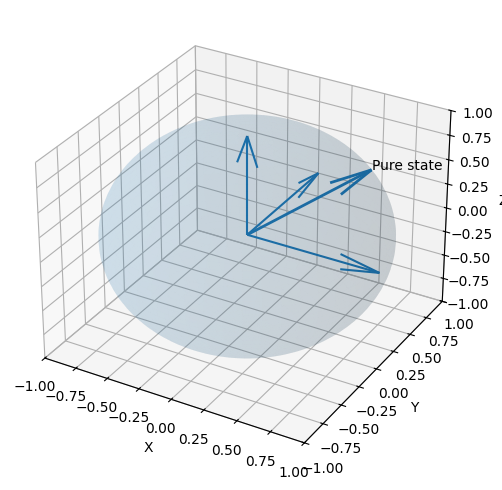

In [ ]:
# Pure State Example (∣ψ⟩=cos(θ/2)∣0⟩ + e^iϕ sin(θ/2)∣1⟩)

theta = np.pi/3
phi = np.pi/4

psi = np.array([
    np.cos(theta/2),
    np.exp(1j*phi)*np.sin(theta/2)
])

rho = np.outer(psi, np.conjugate(psi))

r = bloch_vector_from_density(rho)

print("Bloch Vector:", r)
print("Purity:", purity(rho))

plot_bloch([r], ["Pure state"])  # Purity should be ≈ 1 and the Vector lies on sphere surface

Bloch Vector: [0.  0.  0.4]
Purity: 0.58


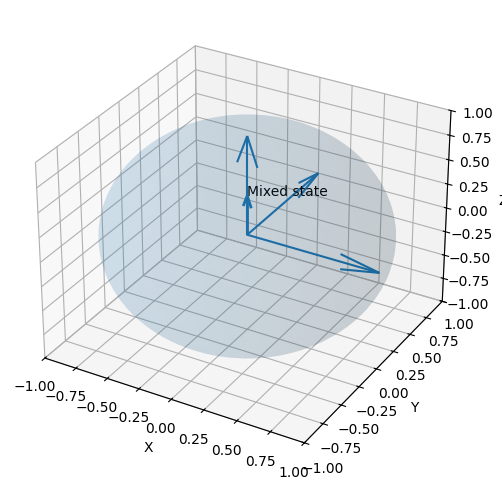

In [ ]:
# Mixed State Example
# Consider the example state: ρ=0.7∣0⟩⟨0∣+0.3∣1⟩⟨1∣

rho_mixed = 0.7*np.array([[1,0],[0,0]]) + 0.3*np.array([[0,0],[0,1]])

r_mixed = bloch_vector_from_density(rho_mixed)

print("Bloch Vector:", r_mixed)
print("Purity:", purity(rho_mixed))

plot_bloch([r_mixed], ["Mixed state"]) # Observe: Vector inside sphere and Purity < 1

Bloch Vector: [0. 0. 0.]
Purity: 0.5


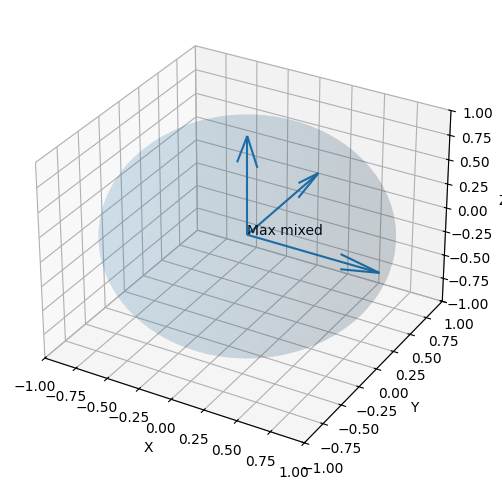

In [ ]:
# Maximally Mixed State: ρ=I/2

rho_max = 0.5*I
r_max = bloch_vector_from_density(rho_max)

print("Bloch Vector:", r_max)
print("Purity:", purity(rho_max))

plot_bloch([r_max], ["Max mixed"]) # It should give us: Vector ≈ (0,0,0) i.e. Center of sphere and Purity = 0.5​

In [ ]:
# Unitary Rotation = Bloch Rotation
# Rotation around Z-axis: U=e−iθσz​/2

theta = np.pi/2

U = np.cos(theta/2)*I - 1j*np.sin(theta/2)*sigma_z

rho_rot = U @ rho @ U.conj().T

r_rot = bloch_vector_from_density(rho_rot)

plot_bloch([r, r_rot], ["Original", "Rotated"])
# We should see: Vector rotates around Z-axis and the Length is preserved. Unitary = rigid rotation

In [ ]:
# Depolarizing Channel (Shrinking): ρ′ = (1−p).ρ + p.I/2​
p = 0.4

rho_dep = (1-p)*rho + p*0.5*I
r_dep = bloch_vector_from_density(rho_dep)

plot_bloch([r, r_dep], ["Original", "After depolarizing"])

print("Original Purity:", purity(rho))
print("After Noise Purity:", purity(rho_dep))

# We should observe: Vector shrinks and moves toward center. Purity decreases Noise = contraction

In [ ]:
#*************************************************#
# Numerical MCQs # MCQ 1: A state has Bloch vector: r = (0,0,0.8). What is its purity?
#*************************************************#

print("----- MCQ 1 -----")

r1 = np.array([0,0,0.8])

r_norm_sq = np.dot(r1,r1)
purity1 = purity_from_r(r1)

print("Bloch vector r =", r1)
print("|r|^2 =", r_norm_sq)
print("Purity = (1 + |r|^2)/2")
print("Purity =", purity1) # Expected answer: 0.82

In [ ]:
#*************************************************#
# MCQ 2: Rotation Around Z-axis. Initial state: ∣+⟩=(​∣0⟩+∣1⟩​)/sqrt(2). Apply rotation: U=e−i2π​σz​/2.
# Predict: Where does the Bloch vector move? Does purity change?
#*************************************************#

print("----- Question 2: Z-rotation -----")

# |+> state
psi = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
rho = np.outer(psi, np.conjugate(psi))

r_initial = bloch_vector(rho)

# Rotation angle
theta = np.pi/2

U = np.cos(theta/2)*I - 1j*np.sin(theta/2)*sigma_z
rho_rot = U @ rho @ U.conj().T

r_rot = bloch_vector(rho_rot)

print("Initial Bloch vector:", r_initial)
print("Rotated Bloch vector:", r_rot)

plot_bloch([r_initial, r_rot], ["Initial", "After Rz"]) # Rotation around Z. Vector moves in XY plane amd the Radius is preserved

In [ ]:
#*************************************************#
# MCQ 3: Rotation Around X-axis: Start from ∣0⟩, Apply: Rx​(π), Where does it go?
#*************************************************#

print("----- Question 3: X-rotation -----")

# |0>
psi0 = np.array([1,0])
rho0 = np.outer(psi0, np.conjugate(psi0))

r_initial = bloch_vector(rho0)

theta = np.pi
U = np.cos(theta/2)*I - 1j*np.sin(theta/2)*sigma_x

rho_rot = U @ rho0 @ U.conj().T
r_rot = bloch_vector(rho_rot)

print("Initial Bloch vector:", r_initial)
print("After Rx(pi):", r_rot)

plot_bloch([r_initial, r_rot], ["|0>", "After Rx(pi)"])
# North pole → South pole (|0⟩ → |1⟩)

In [ ]:
#*************************************************#
# MCQ 4: Arbitrary Axis Rotation - Rotate around axis: n^=​1/sqrt(3)​(1,1,1). Consider the Initial state: ∣0⟩. Angle: θ=π/3
#*************************************************#

print("----- Question 4: Arbitrary Axis Rotation -----")

# Normalize axis
n = np.array([1,1,1])
n = n / np.linalg.norm(n)

# Construct generator
sigma_n = n[0]*sigma_x + n[1]*sigma_y + n[2]*sigma_z

theta = np.pi/3

U = np.cos(theta/2)*I - 1j*np.sin(theta/2)*sigma_n

# Initial state |0>
psi0 = np.array([1,0])
rho0 = np.outer(psi0, np.conjugate(psi0))

r_initial = bloch_vector(rho0)

rho_rot = U @ rho0 @ U.conj().T
r_rot = bloch_vector(rho_rot)

print("Initial Bloch vector:", r_initial)
print("After rotation:", r_rot)

plot_bloch([r_initial, r_rot], ["Initial", "Rotated"])

In [ ]:
#*************************************************#
# MCQ 5: If depolarizing parameter p=1, what is the final state? ρ′=(1−p)ρ + p.I/2​
#*************************************************#

print("\n----- MCQ 5 -----")

# Take initial pure state |0><0|
rho = np.array([[1,0],[0,0]])

p = 1

rho_final = (1-p)*rho + p*(I/2)

print("Final density matrix:\n", rho_final)

r_final = bloch_vector_from_density(rho_final)

print("Bloch vector =", r_final)
print("Purity =", np.trace(rho_final @ rho_final)) # We should see 1/2.I as the output.

In [ ]:
#*************************************************#
# MCQ 6: If ∣r∣=1, what type of state is it?
#*************************************************#

print("\n----- MCQ 6 -----")

r3 = np.array([1,0,0])

print("|r| =", np.linalg.norm(r3))

purity3 = purity_from_r(r3)

print("Purity =", purity3)
# Purity = 1 → Pure state

In [ ]:
#*************************************************#
# MCQ 7: If purity = 0.6, find ∣r∣. Purity=(1+r2​)/2
#*************************************************#

print("\n----- MCQ 7 -----")

purity_given = 0.6

r_value = r_from_purity(purity_given)

print("Given purity =", purity_given)
print("|r| = sqrt(2P - 1)")
print("|r| =", r_value) # Expected: ∣r∣=sqrt(0.2)

In [ ]:
print("\n----- MCQ 8: Verification of Purity in two ways (From Density Matrix and Bloch Sphere) -----")

r = np.array([0.3, 0.4, 0.5])

rho = 0.5*(I + r[0]*sigma_x + r[1]*sigma_y + r[2]*sigma_z)

purity_density = np.real(np.trace(rho @ rho))
purity_bloch = purity_from_r(r)

print("Purity from density matrix =", purity_density)
print("Purity from Bloch formula   =", purity_bloch)
